# Correlation of POP2 Predictions for Round 2

In [37]:
import pandas as pd
# pop2_preds = pd.read_csv('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_predicted_activity.csv')
pop2_preds = pd.read_csv('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_20members_predicted_activity.csv')
pop2_preds = pop2_preds.set_index('seq_id')
model_columns = [c for c in pop2_preds.columns if c.startswith('model_')]

In [38]:
BETA = 1.0
pop2_preds['has_F61'] = pop2_preds.index.str.contains('F61')
pop2_preds['mean'] = pop2_preds[model_columns].mean(axis=1)
pop2_preds['stddev'] = pop2_preds[model_columns].std(axis=1)
pop2_preds['score'] = pop2_preds['mean'] + BETA * pop2_preds['stddev']

pop2_preds = pop2_preds.sort_values('score', ascending=False)


In [72]:
pop2_preds[model_columns] = pop2_preds[model_columns].apply(lambda x: (x - x.mean()) / x.std(), axis=0)

In [75]:
import torch
import pandas as pd
from botorch.models.ensemble import EnsembleModel
from torch import Tensor
from botorch.acquisition import qUpperConfidenceBound
from botorch.optim import optimize_acqf_discrete

# pop2_df: index = seq_id, columns = model_1 … model_20 (float scores)
QUCB_BETA  = 4.0                      # exploration weight – tune as you like
Q     = 24                      # slate size

pop2_subset = pop2_preds[model_columns].head(10000).sample(frac=1.0)

N, S = pop2_subset.shape          # N ≈ 20 000 ; S = 20 models
assert S == len(model_columns), "Expect one column per model"

# tensor shape  (S, N)  == (ensemble, candidates)
pred_tensor = torch.tensor(pop2_preds[model_columns].values.T, dtype=torch.float32)  # (20, N)
seq_ids     = pop2_preds[model_columns].index.to_numpy()                             # (N,)
choices = torch.arange(N, dtype=torch.long).unsqueeze(-1)   # (N, 1)


class PrecomputedEnsemble(EnsembleModel):
    def __init__(self, preds: Tensor):
        """
        preds : (S, N)   where S = # models (20) and N = # sequences
        """
        super().__init__()
        self.register_buffer("preds", preds)   # not trainable
        self._num_outputs = 1                  # tells BoTorch that m = 1

    def forward(self, X: Tensor) -> Tensor:
        """
        Parameters:
        X (Tensor) - A batch_shape x n x d-dim input tensor X.

        Returns
        :
        A batch_shape x s x n x m-dimensional output tensor where s is the size of the ensemble.
        """
        # print(f'X.shape: {X.shape}, expect batch_shape x q (24) x 1')
        idx = X.long().squeeze(-1)             # (..., q)
        out = self.preds[:, idx]               # (S, ..., q)
        # print(f'out.shape: {out.shape}, want batch_shape x ensemble_size x q (24) x 1')
        out = out.movedim(0, 1)               # (..., S, q)
        # print(f'out.shape: {out.shape}, want batch_shape x ensemble_size x q (24) x 1')
        out = out.unsqueeze(-1)               # (..., S, q, 1)
        # print(f'out.shape: {out.shape}, want batch_shape x ensemble_size x q (24) x 1')
        return out

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device('cpu')

model = PrecomputedEnsemble(pred_tensor.to(device)).eval()
acqf  = qUpperConfidenceBound(model=model, beta=QUCB_BETA)

cands, _ = optimize_acqf_discrete(
    acq_function   = acqf,
    choices        = choices.to(device),   # (N, 1)
    q              = Q,
    # sequential     = True,                 # greedy but uses X_pending
    max_batch_size = 2048                  # avoid CUDA OOM
)


KeyboardInterrupt: 

In [212]:
QUCB_BETA = 3.0    # UCB exploration weight
Q         = 24     # slate size

# pop2_df: index = seq_id, columns = model_1 … model_20 (float scores)
pop2_subset = pop2_preds[model_columns].head(1000)
pred_tensor = torch.tensor(
    pop2_subset.values.T, dtype=torch.float32
)  # (S, N) = (ensemble, candidates)
seq_ids = pop2_subset.index.to_numpy()  # (N,)

S, N = pred_tensor.shape
assert S == len(model_columns)

# compute prior means, deviations, and full covariance
means = pred_tensor.mean(dim=0)          # (N,)
devs  = pred_tensor - means              # (S, N)
# sample‐covariance matrix (N×N):
Cov   = (devs.T @ devs) / S              # (N, N)
vars  = Cov.diag()                       # (N,)

# greedy Kriging‐Believer slate selection (see https://www.cs.ubc.ca/labs/algorithms/EARG/stack/2010_CI_Ginsbourger-ParallelKriging.pdf)
selected = []

for _ in range(Q):
    # 1) marginal UCB scores
    ucb = means + QUCB_BETA * vars.sqrt()        # (N,)
    if selected:
        ucb[selected] = -float("inf")            # mask out already‐picked

    # 2) pick best
    idx = int(ucb.argmax().item())
    selected.append(idx)

    # 3) fantasy‐conditioning where you imagine that you pick that sequence: Schur complement to zero covariances with idx (same as covariance thing i wrote a bit back)
    cov_i = Cov[:, idx].clone()                  # (N,)
    v_i   = vars[idx].item()                     # scalar Var(x_idx)
    # Cov_new = Cov - (cov_i outer cov_i) / Var_i
    Cov   = Cov - cov_i.unsqueeze(1) * cov_i.unsqueeze(0) / v_i
    vars  = Cov.diag()                           # update variances

#  map back to your sequence IDs
chosen_seq_ids = seq_ids[selected]               # length Q
print("Chosen slate (seq_ids):", chosen_seq_ids)

Chosen slate (seq_ids): ['G429R_R512E' 'H8R_G429R' 'Q237E_M320R' 'Y405R_G429R' 'M320R_G429R'
 'H8K_G429R' 'H8Q_G429R' 'G255R_G429R' 'D46R_G429R' 'E42R_G429R'
 'G429R_T473E' 'T9R_G429R' 'S336R_G429R' 'F316R_G429R' 'M320G_G429R'
 'E251R_G429R' 'E251N_G429R' 'D321P_G429R' 'Y405G_G429R' 'Q237E_T473E'
 'M320R_T390R' 'G429R_M440R' 'F58R_G429R' 'D46Q_G429R']


# Constant Liar

In [89]:
import torch

# --- Constants and data setup ---
QUCB_BETA = 1.0    # UCB exploration weight
Q         = 24     # slate size
TAU2      = 1e-3   # Variance floor for numerical stability

# pop2_preds: DataFrame indexed by seq_id, cols = model_1 … model_20
subset_df = pop2_preds.sort_values('score', ascending=False)[model_columns].head(10000)
pred_tensor  = torch.tensor(subset_df.values.T, dtype=torch.float32)  # (S, N)
seq_ids      = subset_df.index.to_numpy()                             # (N,)

S, N = pred_tensor.shape
assert S == len(model_columns), "Expect one column per model"

# means, deviations, and full covariance 
means = pred_tensor.mean(dim=0)          # (N,)
devs  = pred_tensor - means              # (S, N)
Cov   = (devs.T @ devs) / S              # (N, N)
vars  = Cov.diag().clamp_min(TAU2)       # (N,)
sigmas = vars.sqrt()                     # (N,)

# constant liar setup: choose L as the ****minimum**** prior mean 
# very adversarial
L = means.min().item()

# greedy Constant Liar batch‐UCB selection 
selected = []

for _ in range(Q):
    # 1) compute marginal UCB scores with current means and variances
    ucb = means + QUCB_BETA * sigmas
    ucb[selected] = -float("inf")  # mask out already‐picked

    # 2) select best candidate
    idx = int(ucb.argmax().item())
    selected.append(idx)
    print(f'Selecting {seq_ids[idx]} with UCB: {ucb[idx]} = {means[idx]} + {QUCB_BETA} * {sigmas[idx]}')

    # 3) "lie" by imagining a ***bad*** constant observation y = L at idx:
    cov_i = Cov[:, idx].clone()        # (N,)
    v_i   = vars[idx].item()           # Var at idx

    # 4) update posterior means conditional on fake bad y=L
    #     μ_new = μ + cov_i * (L - μ[idx]) / v_i
    means = means + cov_i * (L - means[idx]) / (v_i + TAU2)
    # if any(means > 1000):
    #     problem_indices = torch.where(means > 100)[0]
    #     print(f'means: {means[problem_indices[0]]}')
    #     print(f'cov_i: {cov_i[problem_indices[0]]}')
    #     print(f'v_i: {v_i}')
    #     print(f'L: {L}')

    # 5) update covariance via Schur complement, same as KG believer
    Cov   = Cov - torch.outer(cov_i, cov_i) / (v_i + TAU2)
    Cov    = 0.5 * (Cov + Cov.T)         # re-symmetrise
    vars  = Cov.diag().clamp_min(TAU2)
    sigmas = vars.sqrt()                # update std devs

# map back to sequence IDs 
constant_liar_chosen_seq_ids = seq_ids[selected]     # length Q
print("Constant Liar UCB slate:", constant_liar_chosen_seq_ids)

Selecting G429R_R512E with UCB: 6.261539459228516 = 4.170714378356934 + 1.0 * 2.090825080871582
Selecting M320R_G429R with UCB: 3.695410966873169 = 2.9196937084198 + 1.0 * 0.7757172584533691
Selecting F61L_Y327A with UCB: 3.634493589401245 = 3.0472874641418457 + 1.0 * 0.5872061252593994
Selecting N94A_G429R with UCB: 4.3286566734313965 = 3.753272533416748 + 1.0 * 0.5753840208053589
Selecting D46Y_Q237E with UCB: 3.6517491340637207 = 3.33955717086792 + 1.0 * 0.3121918737888336
Selecting T154K_G429R with UCB: 5.171380043029785 = 4.8863525390625 + 1.0 * 0.28502774238586426
Selecting F61L_Y296R with UCB: 6.420923233032227 = 5.9601898193359375 + 1.0 * 0.4607333838939667
Selecting M232R_Q237E with UCB: 7.6793036460876465 = 7.137811660766602 + 1.0 * 0.5414920449256897
Selecting H249M_G429R with UCB: 7.5968337059021 = 7.40804386138916 + 1.0 * 0.18878981471061707
Selecting F61L_Y405L with UCB: 9.650580406188965 = 9.44135570526123 + 1.0 * 0.20922501385211945
Selecting Q237E_V485T with UCB: 14.14

In [63]:
tmp = pop2_preds.reset_index()
tmp[tmp.seq_id.isin(constant_liar_chosen_seq_ids)]

,seq_id,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,...,model_15,model_16,model_17,model_18,model_19,relevant_measured_mutants,has_F61,mean,stddev,score
1,H8R_G429R,8.363398,7.001700,11.497694,12.595005,8.643625,11.101084,8.388971,11.548106,4.884120,...,10.826274,12.336628,10.164894,7.282461,10.194645,G429R,False,10.282528,3.419841,13.702368
2,M320R_G429R,8.193842,6.785112,11.329653,12.589594,7.881956,12.239289,8.733461,11.980666,5.814997,...,10.541990,11.451654,9.986631,7.474420,11.591529,G429R,False,10.289430,3.360288,13.649718
3,H8K_G429R,8.315628,7.205994,11.494868,13.241230,8.867852,10.933529,8.036794,12.345622,5.242832,...,10.654884,11.273317,10.162586,6.896938,10.360414,G429R,False,10.345540,3.276941,13.622481
7,S336R_G429R,7.534483,6.797286,10.448284,11.994072,7.058538,11.585176,8.494439,10.384909,4.059681,...,10.124520,12.160902,9.955482,7.027063,10.191597,G429R,False,9.586528,3.285353,12.871880
16,F316R_G429R,6.786061,6.163265,10.411907,10.733719,7.174463,10.299702,7.985191,9.597485,4.589100,...,8.958736,10.822444,7.668164,6.642424,9.987465,G429R,False,9.013282,3.377516,12.390798
19,E251N_G429R,6.391207,7.261906,9.658783,12.107056,7.743426,9.925766,6.916886,9.431565,3.822438,...,9.750324,10.233568,8.522197,7.552806,9.141582,G429R,False,9.062923,3.180142,12.243065
23,S319R_G429R,6.120954,5.555174,9.464609,11.586121,7.400074,9.902062,8.135212,9.234393,3.824722,...,9.349546,11.645379,9.477851,6.529107,8.725561,G429R,False,8.917517,3.221145,12.138662
38,E84R_G429R,7.212672,6.819106,9.830864,10.649622,6.272683,10.068569,7.175446,8.779764,3.933857,...,9.016975,11.103699,8.711738,6.405700,9.703909,G429R,False,8.724470,3.139540,11.864010
52,S57R_G429R,6.216863,5.881634,9.302403,11.282282,6.846902,9.801954,7.801969,8.789379,3.629928,...,9.459819,10.960232,9.340194,6.015596,8.925379,G429R,False,8.636956,3.081863,11.718819
82,A113R_G429R,5.206362,4.921590,9.378937,10.151905,5.997888,9.669689,8.292272,7.979350,3.299203,...,8.866730,11.324401,8.489630,5.412396,9.088041,G429R,False,8.127721,3.244620,11.372341


In [64]:
tmp = pop2_preds.reset_index()
tmp[tmp.has_F61]

,seq_id,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,...,model_15,model_16,model_17,model_18,model_19,relevant_measured_mutants,has_F61,mean,stddev,score
159,F61L_R512E,8.121291,2.323013,8.295891,8.713568,3.395189,10.019321,0.511057,10.395504,2.771525,...,7.524925,3.495778,3.026156,3.516439,6.557068,F61L,True,6.443463,4.474766,10.918228
568,F61L_G429R,5.607446,4.080263,6.682034,8.319393,5.167726,7.572310,5.592448,7.081932,2.861856,...,7.917335,9.331543,7.678822,4.241807,6.993842,"F61L, G429R",True,6.987704,3.108444,10.096148
570,F61L_Y405R,5.192829,2.256663,6.052325,7.927012,5.214235,10.310615,6.268258,8.528104,3.183923,...,8.215345,6.188716,5.122004,3.901354,6.581118,F61L,True,6.899215,3.192609,10.091823
587,H8R_F61L,5.964124,4.026549,6.861608,7.303901,5.489596,7.818615,5.155643,8.944336,3.213621,...,7.822535,6.520288,6.341713,4.918001,7.512979,F61L,True,6.904285,3.169435,10.073720
692,F61V_G429R,5.695362,3.719721,6.405242,8.027154,4.991472,7.702826,5.160381,6.672629,2.357251,...,8.025628,9.048092,7.959445,4.266771,6.473689,"F61L, G429R",True,6.755147,3.203841,9.958988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106899,F61L_C79Q,-3.001543,-6.762668,-6.192377,-1.604056,-5.726709,-4.419064,-6.554000,0.359985,-3.816558,...,-7.005552,-5.649729,-7.123659,-4.333392,-3.364407,F61L,True,-4.373876,2.606564,-1.767312
106935,F61L_C79W,-3.798018,-9.258610,-6.790496,-2.559452,-8.359314,-3.278291,-8.351676,-0.543420,-3.580931,...,-6.091410,-7.839205,-11.250388,-6.278251,-3.449810,F61L,True,-5.657274,3.275207,-2.382068
106960,F61L_C79E,-4.577949,-9.725159,-6.446202,-2.278095,-9.344166,-2.784919,-10.384263,-1.968151,-4.339166,...,-7.441114,-9.784784,-11.209591,-6.765278,-5.122981,F61L,True,-6.248748,3.099522,-3.149226
106974,F61L_C79P,-4.551313,-10.220489,-6.749636,-3.521687,-9.246048,-2.747263,-10.230613,-2.104037,-4.509568,...,-7.799383,-9.564060,-11.004791,-6.637867,-4.975694,F61L,True,-6.429761,2.864047,-3.565714


In [84]:
selection_df = pd.concat([
    # pop2_preds.iloc[:24]
    # pop2_preds[pop2_preds.index.isin(constant_liar_chosen_seq_ids)],
    pop2_preds.head(30),
    # pop2_preds.iloc[[63]],
    # pop2_preds.iloc[[64]]
    # pop2_preds[pop2_preds.has_F61].head(30)
])

selection_df.relevant_measured_mutants.value_counts()

relevant_measured_mutants
G429R                      25
Q237E                       2
T390R                       2
D46A, D46L, D46V, G429R     1
Name: count, dtype: int64

In [81]:

import plotly.express as px

# Calculate correlation matrix

corr_matrix = selection_df[model_columns].T.corr()

# Create interactive heatmap
fig = px.imshow(corr_matrix, text_auto=True, color_continuous_scale='RdBu_r', height=800, zmin=0, zmax=1)
fig.update_layout(title=f'Covariance Matrix Heatmap (Beta={BETA})')
fig.show()

In [169]:
import json
with open('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_debug_info.json', 'r') as f:
    debug_info = json.load(f)

In [170]:
df = pd.DataFrame()
for model_idx, model in enumerate(debug_info['finetune_metrics']):
    df = pd.concat([
        df,
        pd.DataFrame({
            'model': model_idx,
            'val_loss': model['val_loss'],
            'epoch': range(len(model['val_loss']))
        })
    ])

<Axes: xlabel='epoch', ylabel='val_loss'>

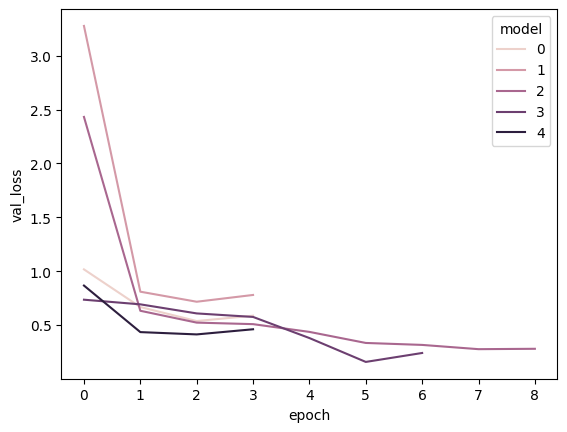

In [171]:
import seaborn as sns
sns.lineplot(
    data=df,
    x='epoch',
    y='val_loss',
    hue='model'
)

# qUCB

In [194]:
cands

tensor([[   3],
        [  15],
        [1657],
        [   1],
        [  64],
        [ 267],
        [  45],
        [  49],
        [5805],
        [ 338],
        [4288],
        [4960],
        [ 133],
        [ 406],
        [  11],
        [  63],
        [3296],
        [   0],
        [   2],
        [   4],
        [   5],
        [   6],
        [   7],
        [   8]])

In [151]:
pred_tensor = model.forward(cands)

In [152]:

mu  = pred_tensor.mean(0)                 # (N,)
std = pred_tensor.std(0)                  # (N,)
print(mu[:10], std[:10])
print("μ range:", float(mu.min()), float(mu.max()))
print("σ range:", float(std.min()), float(std.max()))

tensor([[ 4.1753],
        [12.9594],
        [ 5.5276],
        [ 7.9526],
        [ 9.8725]]) tensor([[1.6107],
        [1.5074],
        [0.9913],
        [0.7069],
        [1.2206]])
μ range: 4.175261974334717 12.959370613098145
σ range: 0.706923246383667 1.6106536388397217
